# MILK10k — Exploratory Data Analysis

**Computer Vision and Speech Recognition · Session 1 homework**

This notebook is the first milestone of the MILK10k course project. Before training
anything, we look at what is actually in the dataset: how many images and lesions
there are, how the labels are distributed, who the patients are, what the images
look like, and which of these facts will break a naive pipeline.

**The clinical task.** MILK10k contains photographs of skin lesions that a
dermatologist judged suspicious enough to look at closely. Each lesion was imaged
twice — once through a **dermatoscope** (polarised light, high magnification, sub-surface
structures visible) and once as a **clinical close-up** (what the naked eye sees).
Most were then biopsied and read by a pathologist, which is where the labels come from.

We want to predict, from the images, whether a lesion is **Benign**, **Malignant** or
**Indeterminate** (`diagnosis_1`), with an optional finer 11-class diagnosis as a
stretch goal. The point is triage: skin cancer is highly curable when caught early and
often lethal when missed, so a useful model is one that **rarely misses a malignant
lesion**, even at the cost of some false alarms. A full write-up is in
[`docs/clinical_task.md`](../docs/clinical_task.md).

## 0. Setup

All reusable code lives in `src/milk10k/` so later sessions can import it rather than
copy-pasting cells. The notebook only orchestrates and narrates.

In [1]:
import sys
from pathlib import Path

# Make the project's `src/` importable from the notebook.
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from milk10k import config, data, plots

config.apply_style()
config.ensure_dirs()

print("pandas", pd.__version__, "| numpy", np.__version__)
print("Dataset directory:", config.DATA_DIR)
print("Dataset present:", config.METADATA_CSV.exists())

pandas 3.0.5 | numpy 2.5.3
Dataset directory: /Users/stanislauslattorff/Desktop/Computer_Vision/data/milk10k
Dataset present: True


> If `Dataset present` is `False`, run `bash scripts/download_data.sh` from the project
> root first. The data (~345 MB, CC-BY-NC) is deliberately not committed to git.

## 1. Loading the four tables

MILK10k ships **two different row units**, and confusing them is the single easiest way
to ruin this project:

| File | Row unit | Rows |
|---|---|---|
| `metadata.csv` | one **image** | 10,480 |
| `supplements/training_gt.csv` | one **lesion** | 5,240 |
| `supplements/training_input.csv` | one **image** | 10,480 |
| `supplements/training_supp.csv` | one **image** | 10,480 |

That 2:1 ratio is not an accident — it is the two-images-per-lesion structure.

In [2]:
meta = data.load_metadata()          # one row per image
gt = data.load_training_gt()         # one row per lesion, 11-class one-hot
inp = data.load_training_input()     # one row per image, MONET concepts + skin tone
supp = data.load_training_supp()     # one row per image, full-text diagnosis

for name, frame in [("metadata", meta), ("training_gt", gt),
                    ("training_input", inp), ("training_supp", supp)]:
    print(f"{name:16s} {frame.shape[0]:>6,} rows x {frame.shape[1]:>2} cols")

print(f"\nunique images : {meta['isic_id'].nunique():,}")
print(f"unique lesions: {meta['lesion_id'].nunique():,}")
print(f"images/lesion : {len(meta) / meta['lesion_id'].nunique():.0f}")

metadata         10,480 rows x 17 cols
training_gt       5,240 rows x 12 cols
training_input   10,480 rows x 17 cols
training_supp    10,480 rows x  4 cols

unique images : 10,480
unique lesions: 5,240
images/lesion : 2


In [3]:
meta.head(3)

,isic_id,attribution,copyright_license,age_approx,anatom_site_general,anatom_site_special,concomitant_biopsy,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_4,diagnosis_confirm_type,image_manipulation,image_type,lesion_id,melanocytic,sex
0,ISIC_0051817,MILK study team,CC-BY-NC,70.0,upper extremity,NaN,True,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, Invasive",NaN,histopathology,instrument only,dermoscopic,IL_1612768,NaN,male
1,ISIC_0073863,MILK study team,CC-BY-NC,5.0,NaN,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Reed",histopathology,instrument only,dermoscopic,IL_2547802,True,female
2,ISIC_0075884,MILK study team,CC-BY-NC,10.0,upper extremity,NaN,True,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Acral",histopathology,instrument only,clinical: close-up,IL_9270970,True,female


### What the columns mean

`metadata.csv` carries a four-level diagnosis hierarchy (`diagnosis_1` … `diagnosis_4`),
going from the coarse triage label down to a specific subtype.

In [4]:
meta[["isic_id", "lesion_id", "image_type",
      "diagnosis_1", "diagnosis_2", "diagnosis_3", "diagnosis_4"]].head(5)

,isic_id,lesion_id,image_type,diagnosis_1,diagnosis_2,diagnosis_3,diagnosis_4
0,ISIC_0051817,IL_1612768,dermoscopic,Malignant,Malignant epidermal proliferations,"Squamous cell carcinoma, Invasive",NaN
1,ISIC_0073863,IL_2547802,dermoscopic,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Reed"
2,ISIC_0075884,IL_9270970,clinical: close-up,Benign,Benign melanocytic proliferations,Nevus,"Nevus, Acral"
3,ISIC_0076255,IL_8089688,dermoscopic,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,NaN
4,ISIC_0077054,IL_5271098,dermoscopic,Malignant,Malignant adnexal epithelial proliferations - ...,Basal cell carcinoma,NaN


## 2. Building the two analysis views

`build_image_level()` joins the 11-class lesion label and the per-image MONET scores onto
the 10,480-row image grain. `build_lesion_level()` then collapses to the 5,240 lesions,
which is the grain any honest train/test split has to work on.

In [5]:
df = data.build_image_level(meta, gt, inp)      # 10,480 rows — one per image
lesion = data.build_lesion_level(df)            # 5,240 rows — one per lesion

print("image level :", df.shape)
print("lesion level:", lesion.shape)
df[["isic_id", "lesion_id", "image_type", "diagnosis_1",
    "label_11", "skin_tone_class"]].head()

image level : (10480, 32)
lesion level: (5240, 15)


,isic_id,lesion_id,image_type,diagnosis_1,label_11,skin_tone_class
0,ISIC_0051817,IL_1612768,dermoscopic,Malignant,SCCKA,4
1,ISIC_0073863,IL_2547802,dermoscopic,Benign,NV,3
2,ISIC_0075884,IL_9270970,clinical: close-up,Benign,NV,3
3,ISIC_0076255,IL_8089688,dermoscopic,Malignant,BCC,4
4,ISIC_0077054,IL_5271098,dermoscopic,Malignant,BCC,3


## 3. Do not trust the structure — check it

Everything downstream rests on a few structural claims. Verify them from the data
rather than believing the slides.

In [6]:
checks = data.check_lesion_consistency(df)
checks

,check,passed,detail
0,Every lesion has exactly 2 images,True,"5,240 / 5,240 lesions"
1,Each lesion has 2 distinct image types,True,"5,240 / 5,240 lesions"
2,isic_id is unique,True,"10,480 unique / 10,480 rows"
3,No duplicated image rows,True,0 duplicates
4,'diagnosis_1' is constant within a lesion,True,0 lesions vary
5,'label_11' is constant within a lesion,True,0 lesions vary
6,'age_approx' is constant within a lesion,True,0 lesions vary
7,'sex' is constant within a lesion,True,0 lesions vary


In [7]:
# Is the 11-class ground truth really single-label?
labels = data.gt_to_label(gt)
print(labels["n_positive"].value_counts().to_string())
print(f"\nLesions without exactly one positive class: {(labels['n_positive'] != 1).sum()}")

n_positive
1    5240

Lesions without exactly one positive class: 0


Every lesion has exactly two images, one of each modality; `isic_id` is unique; the
demographic and label columns are constant within a lesion; and the 11-class target is
genuinely single-label. **The structure holds.**

## 4. Class distribution — the headline problem

This is the plot to draw before anything else.

In [8]:
primary = lesion["diagnosis_1"].value_counts()
primary_pct = (primary / primary.sum() * 100).round(1)
pd.DataFrame({"lesions": primary, "share_%": primary_pct})

,lesions,share_%
diagnosis_1,,
Malignant,3634,69.4
Benign,1483,28.3
Indeterminate,123,2.3


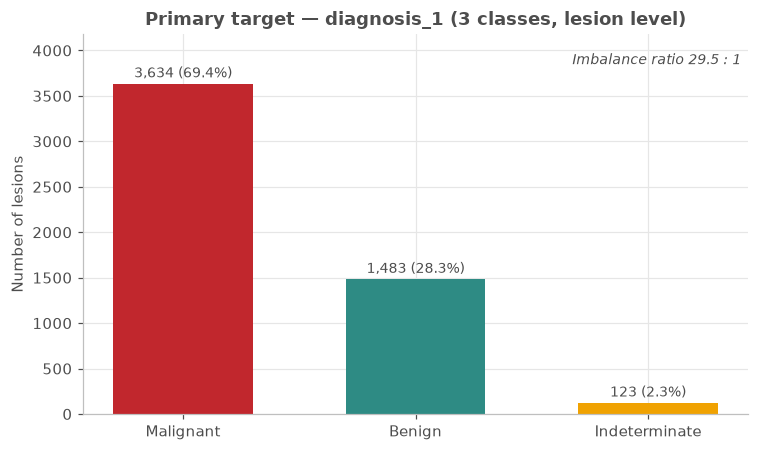

In [9]:
plots.plot_primary_class_distribution(lesion, save_as="fig01_class_distribution_primary.png")
plt.show()

**This is the opposite of what people expect.** Most skin-lesion datasets are dominated by
benign nevi. MILK10k is dominated by *malignant* lesions, because it samples lesions a
dermatologist already found suspicious enough to biopsy — a **selection bias baked into the
data by design**.

The practical consequence: a model that outputs "Malignant" unconditionally scores
~69% accuracy while being clinically worthless. Accuracy is the wrong headline metric here.

In [10]:
majority = primary.max() / primary.sum()
print(f"Always-predict-'{primary.idxmax()}' baseline accuracy: {majority:.1%}")
print(f"...its recall on Benign lesions:                    0.0%")
print(f"\nImbalance ratio (largest:smallest) = {primary.max() / primary.min():.1f} : 1")

Always-predict-'Malignant' baseline accuracy: 69.4%
...its recall on Benign lesions:                    0.0%

Imbalance ratio (largest:smallest) = 29.5 : 1


In [11]:
eleven = lesion["label_11"].value_counts()
pd.DataFrame({
    "diagnosis": [config.DIAGNOSIS_CODES[c] for c in eleven.index],
    "lesions": eleven.values,
    "share_%": (eleven.values / eleven.sum() * 100).round(2),
}, index=eleven.index)

,diagnosis,lesions,share_%
label_11,,,
BCC,Basal cell carcinoma,2522,48.13
NV,Nevus,746,14.24
BKL,Benign keratosis-like lesion,544,10.38
SCCKA,Squamous cell carcinoma / keratoacanthoma,473,9.03
MEL,Melanoma,450,8.59
AKIEC,Actinic keratosis / intraepithelial carcinoma,303,5.78
DF,Dermatofibroma,52,0.99
INF,Inflammatory / infectious,50,0.95
VASC,Vascular lesion,47,0.90


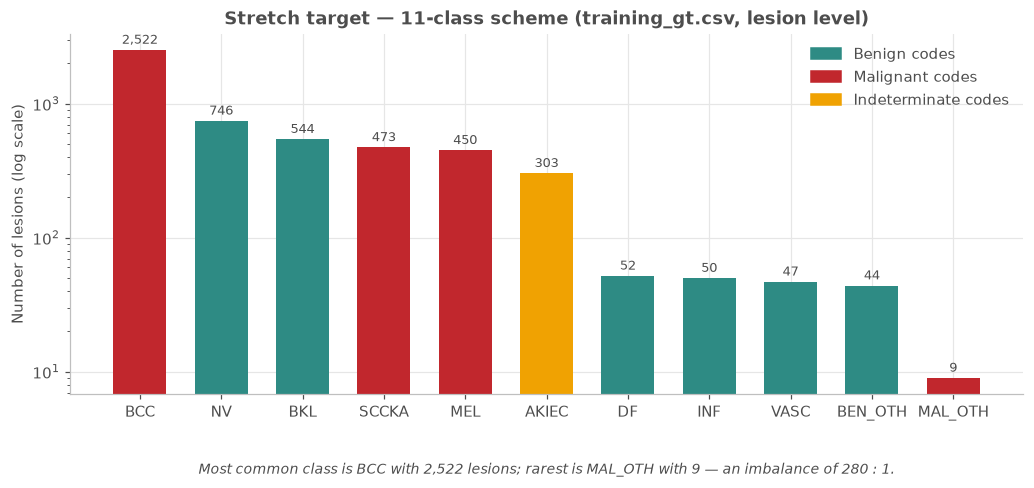

In [12]:
plots.plot_11_class_distribution(lesion, save_as="fig02_class_distribution_11.png")
plt.show()

The 11-class target is far harsher: **BCC has 2,522 lesions, MAL_OTH has 9** — a 280:1
imbalance. Four classes have fewer than 55 lesions, which after a test split leaves barely
a handful of examples. Any 11-class attempt will need class weighting, oversampling, or
merging the rare tail.

### Are the two label schemes consistent?

The 3-class and 11-class targets should be nested. Checking rather than assuming turns up
a genuine subtlety.

In [13]:
hierarchy = data.check_label_hierarchy(lesion)
hierarchy

diagnosis_1,Benign,Malignant,Indeterminate
label_11,,,
BCC,0,2522,0
NV,746,0,0
BKL,544,0,0
SCCKA,0,473,0
MEL,0,450,0
AKIEC,0,180,123
DF,52,0,0
INF,50,0,0
VASC,47,0,0


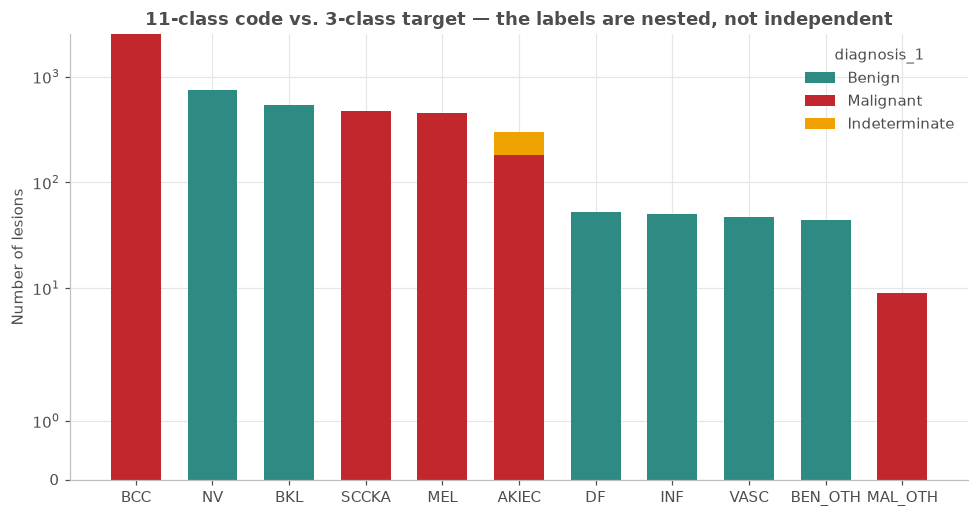

Codes mapping to more than one diagnosis_1 value: ['AKIEC']


In [14]:
plots.plot_diagnosis_hierarchy(lesion, save_as="fig03_diagnosis_hierarchy.png")
plt.show()

print("Codes mapping to more than one diagnosis_1 value:", data.ambiguous_codes(lesion))

Ten of the eleven codes map cleanly onto a single `diagnosis_1` value. **AKIEC does not** —
it splits into 123 *Indeterminate* and 180 *Malignant* lesions. That is clinically sensible
(actinic keratosis and intraepithelial carcinoma sit on a continuum rather than either side
of a line), but it means you **cannot** derive `diagnosis_1` from the 11-class code with a
lookup table, and the *Indeterminate* class is essentially "AKIEC we could not commit on".

## 5. Missing values

Missingness here is structural, not random.

In [15]:
missing = df.isna().mean().sort_values(ascending=False)
missing[missing > 0].to_frame("missing_share").style.format("{:.1%}")

,missing_share
anatom_site_special,98.0%
diagnosis_4,85.5%
melanocytic,77.2%
anatom_site_general,37.3%
diagnosis_3,1.5%
site,0.6%
age_approx,0.4%


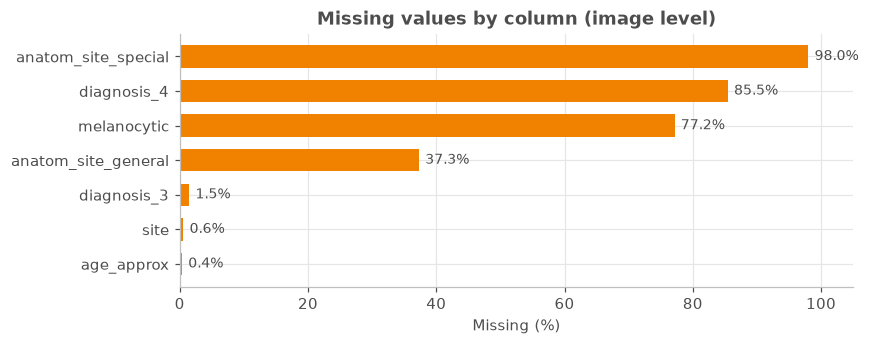

In [16]:
plots.plot_missing_values(df, save_as="fig04_missing_values.png")
plt.show()

- `melanocytic` is missing 77% of the time — but it is never `False`, only `True` or blank.
  It is an *annotation*, not a boolean feature; treating blank as "not melanocytic" would be wrong.
- `anatom_site_general` is missing for 37% of images, so body site can only be used with an
  explicit "unknown" category.
- `diagnosis_4` is missing 86% of the time simply because most diagnoses do not go four
  levels deep.

## 6. Who is in this dataset?

Demographics matter because a model inherits whatever population it was trained on.

In [17]:
lesion[["age_approx"]].describe().T

,count,mean,std,min,25%,50%,75%,max
age_approx,5220.0,61.355364,15.692398,5.0,50.0,65.0,75.0,85.0


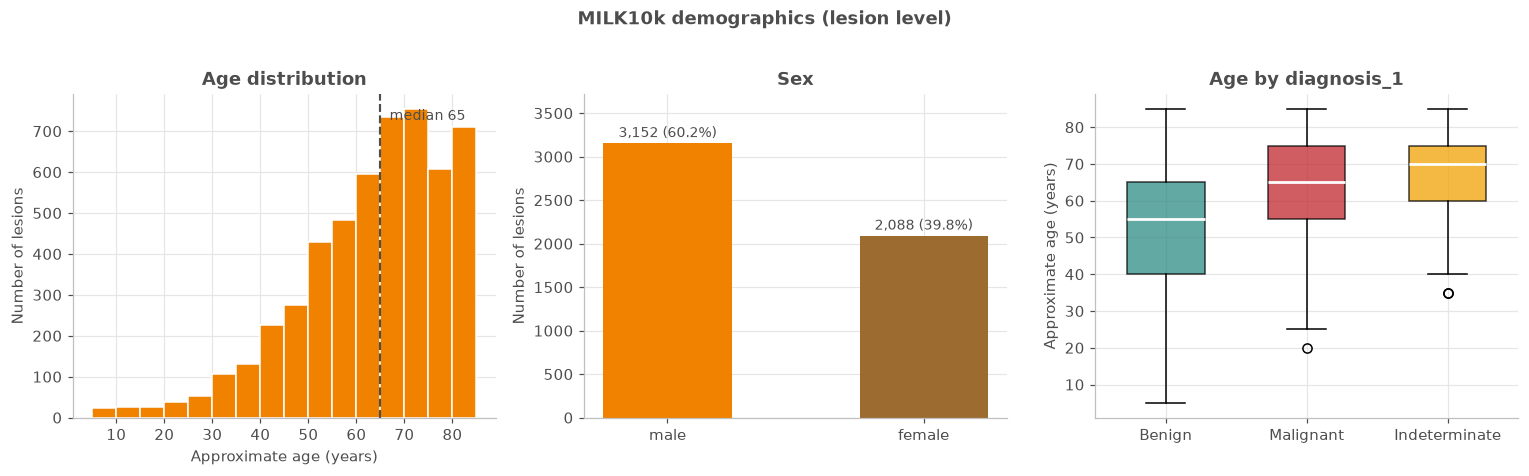

In [18]:
plots.plot_demographics(lesion, save_as="fig05_demographics.png")
plt.show()

In [19]:
pd.crosstab(lesion["sex"], lesion["diagnosis_1"], normalize="index").style.format("{:.1%}")

diagnosis_1,Benign,Indeterminate,Malignant
sex,,,
female,33.2%,1.7%,65.1%
male,25.0%,2.8%,72.2%


Median age is 65 and 60% of lesions come from men — an older, male-skewed population,
consistent with a specialist skin-cancer clinic rather than the general public.
Malignancy rate is visibly higher in men.

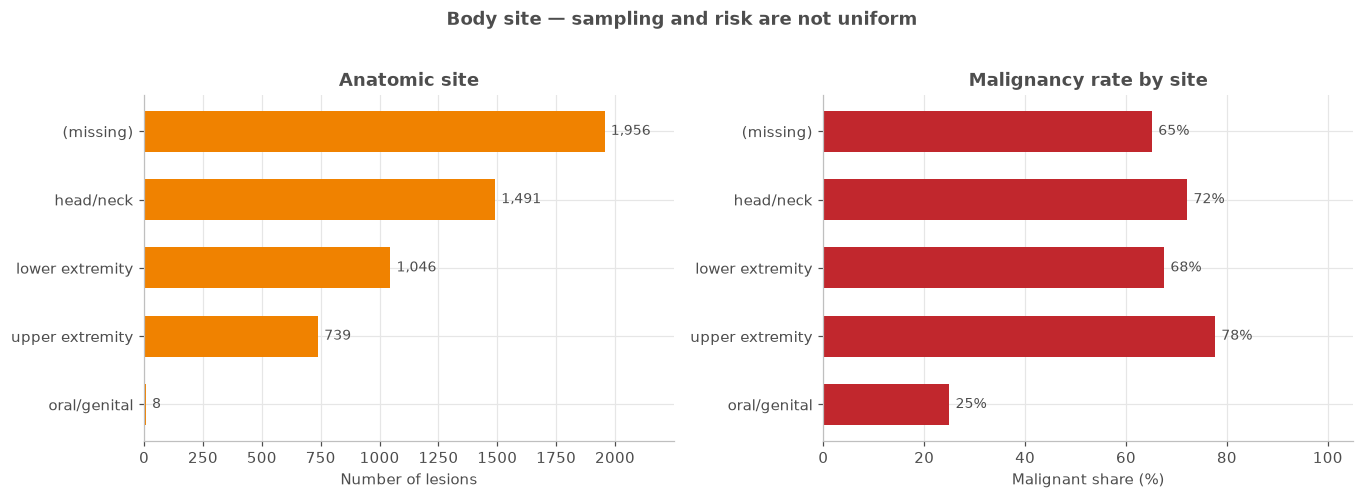

In [20]:
plots.plot_anatomic_site(lesion, save_as="fig06_anatomic_site.png")
plt.show()

Head/neck is both the most common site and one of the most malignant — sun-exposed skin.
Note the large `(missing)` bar: site is unavailable for a substantial share of lesions.

## 7. Skin tone — the fairness slice

This is the check that dermatology AI has historically failed, and it is the reason
MILK10k ships a skin tone class at all.

In [21]:
tone = lesion["skin_tone_class"].value_counts().sort_index()
pd.DataFrame({
    "skin_tone": [config.SKIN_TONE_LABELS.get(int(i), i) for i in tone.index],
    "lesions": tone.values,
    "share_%": (tone.values / tone.sum() * 100).round(1),
}).set_index("skin_tone")

,lesions,share_%
skin_tone,,
0 (unknown/other),6,0.1
I,105,2.0
II,506,9.7
III,3174,60.6
IV,1066,20.3
V,383,7.3


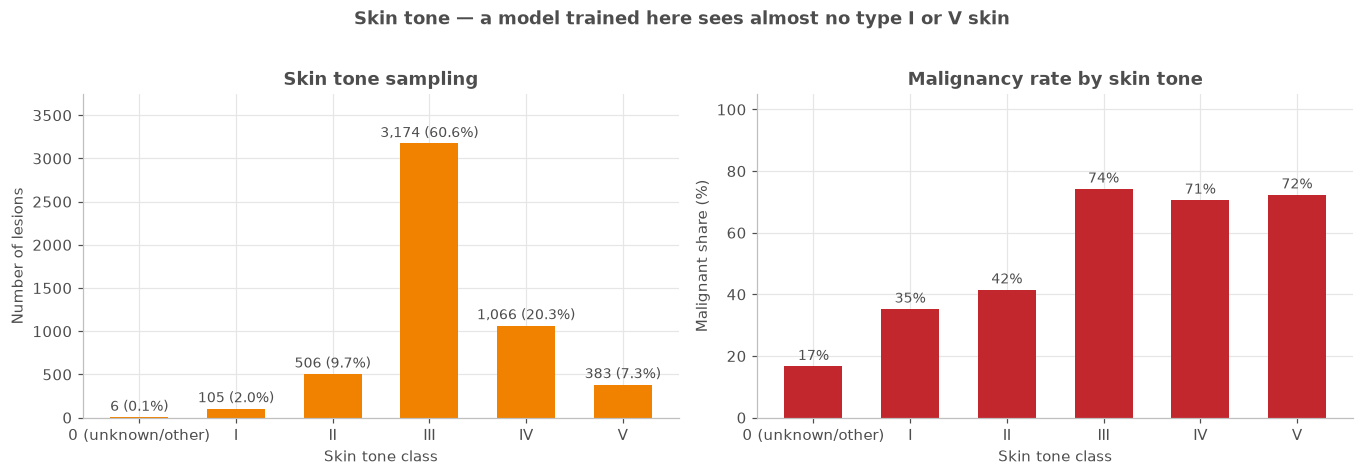

In [22]:
plots.plot_skin_tone(lesion, save_as="fig07_skin_tone.png")
plt.show()

**61% of lesions are a single skin tone class (III)**, and the lightest and darkest tones
together are under 10%. Two consequences:

1. Aggregate metrics will be dominated by type III/IV skin. Per-group recall must be
   reported separately, or failures on under-represented tones stay invisible.
2. The apparent trend of higher malignancy in darker classes is **confounded**, not causal —
   it reflects who gets referred and which body sites get imaged, not skin tone itself.
   With only 105 type-I lesions, the leftmost bars are noisy.

## 8. The images themselves

Metadata is only half the story. Open the actual JPEGs and measure them.

In [23]:
# Reading all 10,480 files is slow; 400 is plenty for a first estimate.
stats = data.sample_image_stats(df, n=400, seed=0)
stats[["width", "height", "megapixels", "file_size_kb", "mean_intensity"]].describe().T.round(1)

,count,mean,std,min,25%,50%,75%,max
width,400.0,600.0,0.0,600.0,600.0,600.0,600.0,600.0
height,400.0,450.0,0.0,450.0,450.0,450.0,450.0,450.0
megapixels,400.0,0.3,0.0,0.3,0.3,0.3,0.3,0.3
file_size_kb,400.0,32.2,9.4,13.1,25.2,30.7,38.9,62.1
mean_intensity,400.0,143.3,21.4,72.7,128.1,142.1,158.2,218.0


In [24]:
stats.groupby("image_type").agg(
    n=("isic_id", "count"),
    mean_width=("width", "mean"),
    mean_height=("height", "mean"),
    mean_megapixels=("megapixels", "mean"),
    mean_file_kb=("file_size_kb", "mean"),
).round(1)

,n,mean_width,mean_height,mean_megapixels,mean_file_kb
image_type,,,,,
clinical: close-up,190,600.0,450.0,0.3,38.1
dermoscopic,210,600.0,450.0,0.3,26.9


In [25]:
print("Distinct (width, height) pairs in the sample:", stats.groupby(["width", "height"]).ngroups)
print("Width range :", stats["width"].min(), "-", stats["width"].max())
print("Height range:", stats["height"].min(), "-", stats["height"].max())

Distinct (width, height) pairs in the sample: 1
Width range : 600 - 600
Height range: 450 - 450


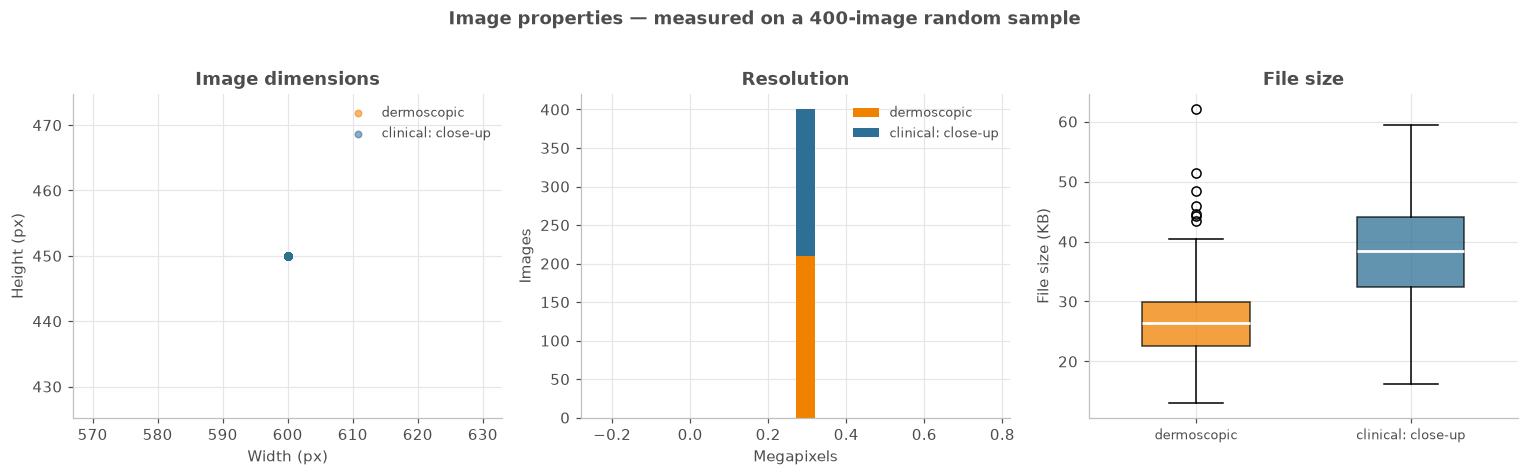

In [26]:
plots.plot_image_properties(stats, save_as="fig08_image_properties.png")
plt.show()

Images are **not** a uniform size, so a resize / crop step is mandatory before batching.

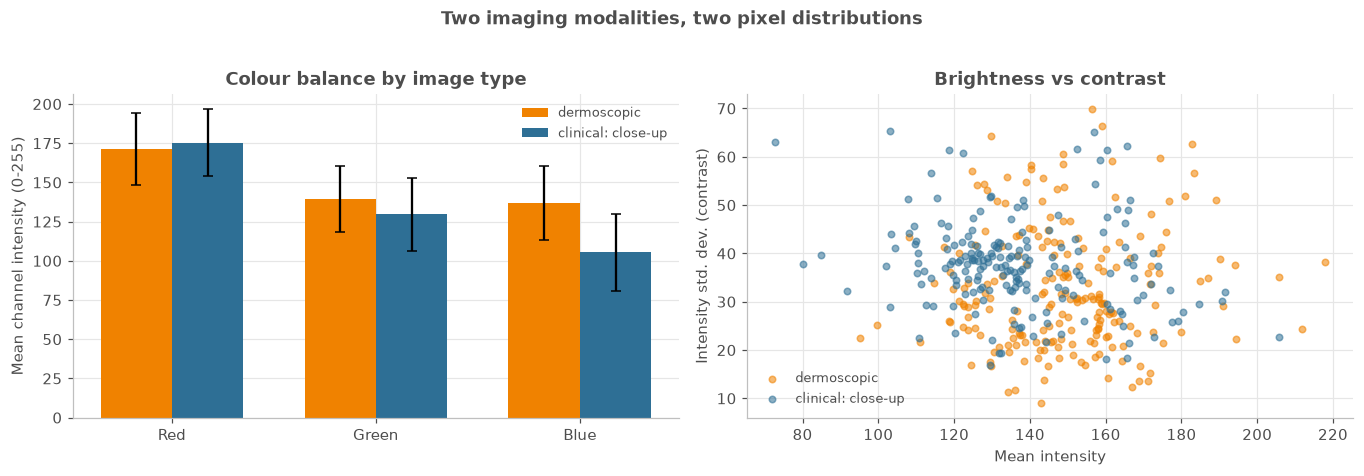

In [27]:
plots.plot_color_statistics(stats, save_as="fig09_color_statistics.png")
plt.show()

Dermoscopic and clinical images have measurably different colour and contrast distributions.
They are two modalities, not two samples of one. Mixing them blindly in a single batch means
the model spends capacity learning "which camera took this" before it learns "is this cancer".

### Looking at one image as numbers

The bridge from "a picture" to "a matrix a model can use".

isic_id   : ISIC_0051817
diagnosis : Malignant / Malignant epidermal proliferations
image_type: dermoscopic
shape     : (450, 600, 3) (height, width, channels)
dtype     : uint8
min / max : 0 / 230


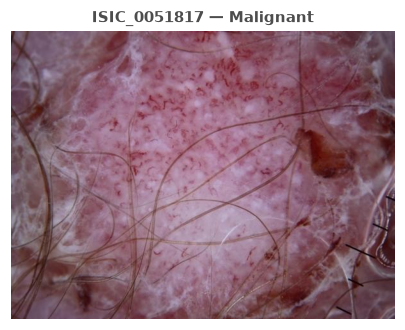

In [28]:
row = df.iloc[0]
img = data.load_image(row["isic_id"])
arr = np.array(img)

print("isic_id   :", row["isic_id"])
print("diagnosis :", row["diagnosis_1"], "/", row["diagnosis_2"])
print("image_type:", row["image_type"])
print("shape     :", arr.shape, "(height, width, channels)")
print("dtype     :", arr.dtype)
print("min / max :", arr.min(), "/", arr.max())

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.imshow(img)
ax.set_title(f"{row['isic_id']} — {row['diagnosis_1']}", fontsize=10)
ax.axis("off"); ax.grid(False)
plt.show()

### One example per diagnosis class

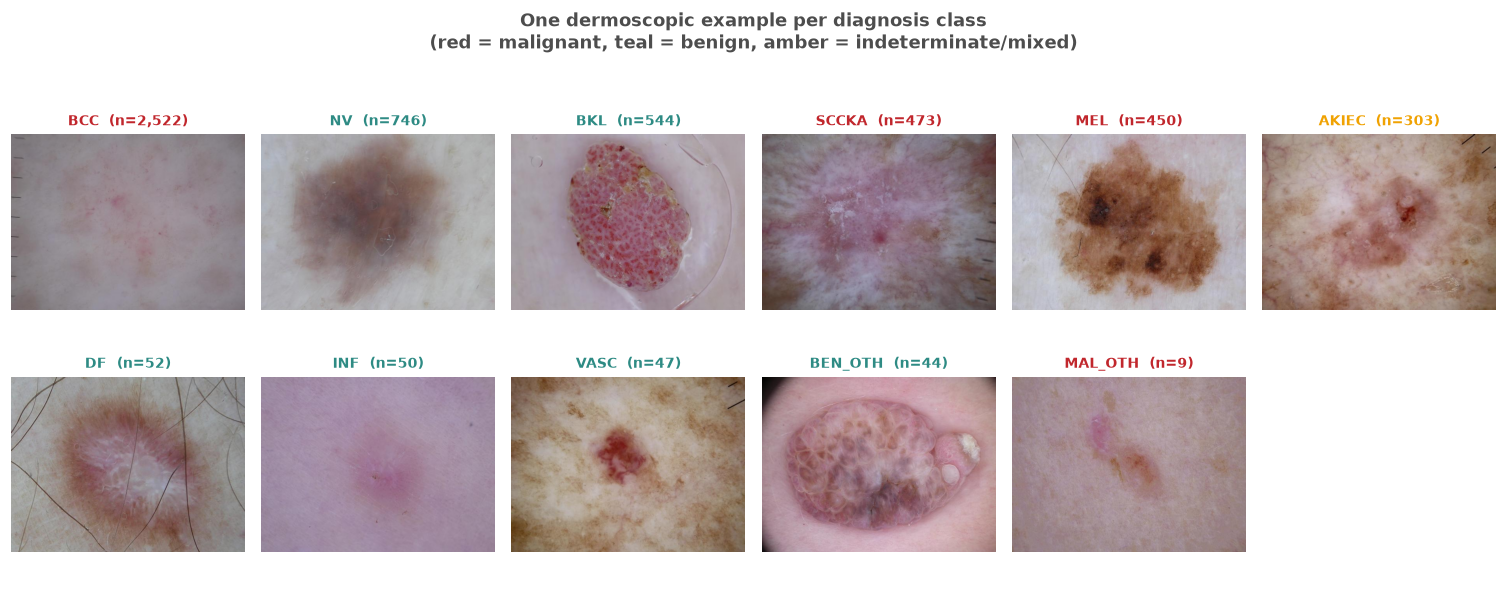

In [29]:
plots.plot_class_gallery(df, save_as="fig10_class_gallery.png")
plt.show()

Note how little separates some of these visually. BCC (the majority class) can be a
barely-pigmented pink patch, while a benign nevus is often the *more* dramatic-looking
lesion. This is why the task is hard and why colour/size heuristics fail.

### Two images, one lesion

The most consequential structural fact in the dataset.

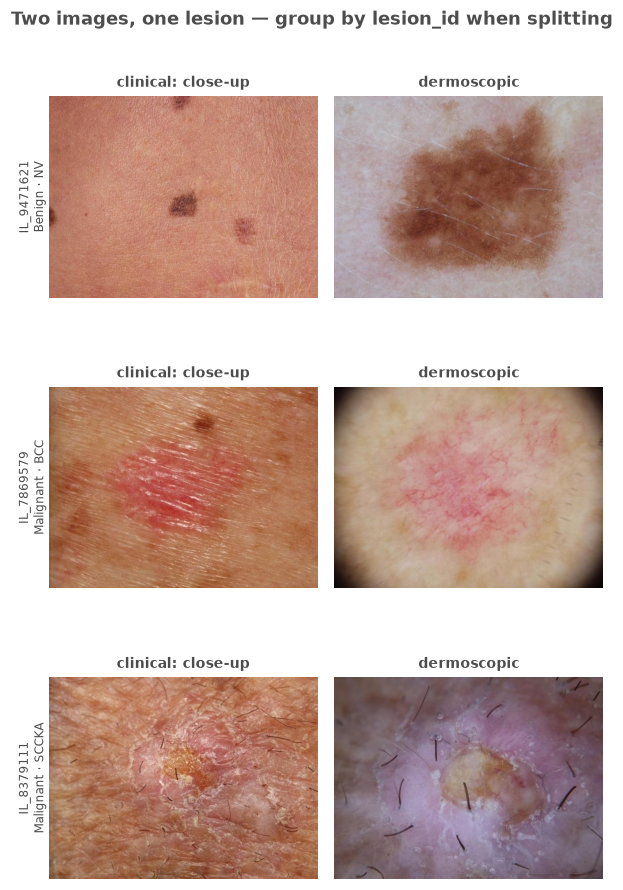

In [30]:
plots.plot_lesion_pairs(df, n_lesions=3, save_as="fig11_lesion_pairs.png")
plt.show()

Same lesion, same label, two very different images. If a random **row** split puts the
dermoscopic image in train and the clinical image in test, the model has effectively seen the
test case. Scores go up; real performance does not. **Split on `lesion_id`.**

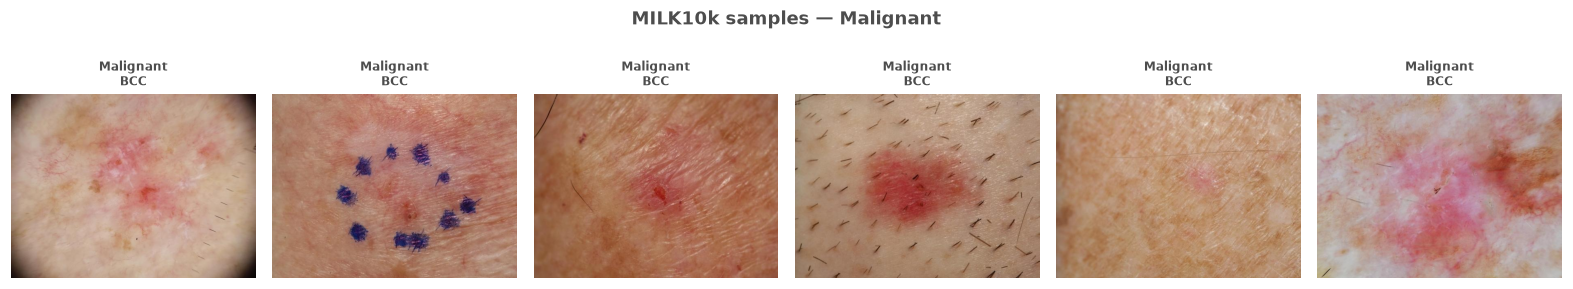

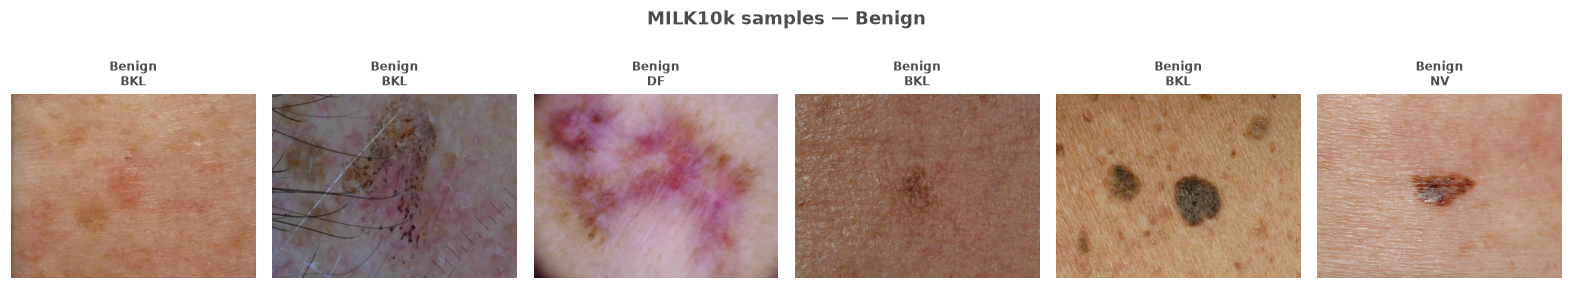

In [31]:
plots.show_samples(df, n=6, diagnosis="Malignant", save_as="fig12_samples_malignant.png")
plt.show()
plots.show_samples(df, n=6, diagnosis="Benign", save_as="fig13_samples_benign.png")
plt.show()

## 9. MONET concept scores

`training_input.csv` ships seven per-image scores from MONET, an image–text foundation
model. Each score says how strongly a human-readable visual concept ("hair", "ulceration",
"pigmented") is present. They are useful both as tabular features and as an interpretability
handle.

In [32]:
monet_cols = [c for c in df.columns if c.startswith("MONET_")]
df.groupby("image_type")[monet_cols].mean().T.round(3)

image_type,clinical: close-up,dermoscopic
MONET_ulceration_crust,0.356,0.364
MONET_hair,0.181,0.382
MONET_vasculature_vessels,0.018,0.223
MONET_erythema,0.360,0.352
MONET_pigmented,0.268,0.357
MONET_gel_water_drop_fluid_dermoscopy_liquid,0.162,0.326
MONET_skin_markings_pen_ink_purple_pen,0.184,0.295


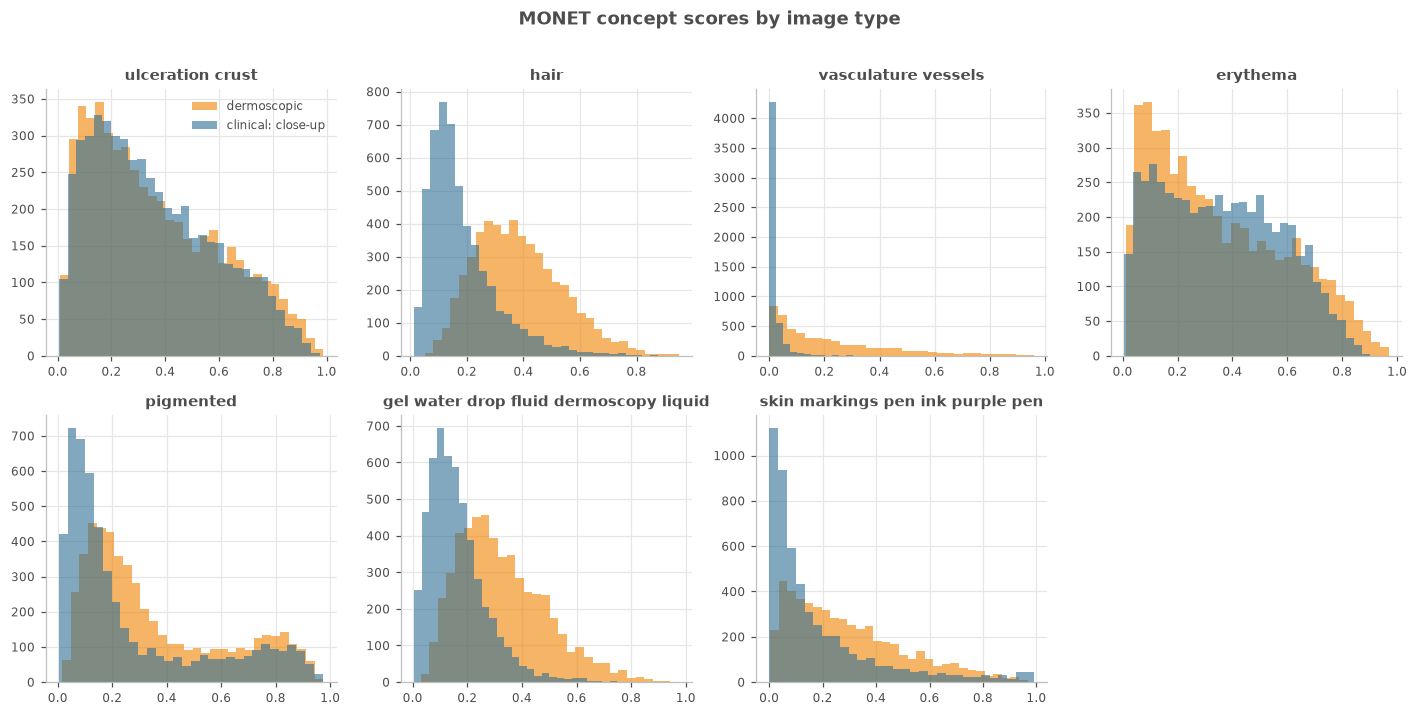

In [33]:
plots.plot_monet_by_image_type(df, save_as="fig14_monet_by_image_type.png")
plt.show()

`vasculature_vessels` averages 0.22 on dermoscopic images against 0.02 on clinical ones —
exactly what a dermatoscope is *for*: it makes sub-surface vessels visible. The
`gel_water_drop` concept behaves the same way, because immersion fluid is part of the
dermoscopic procedure. These scores are modality-dependent and must not be pooled naively.

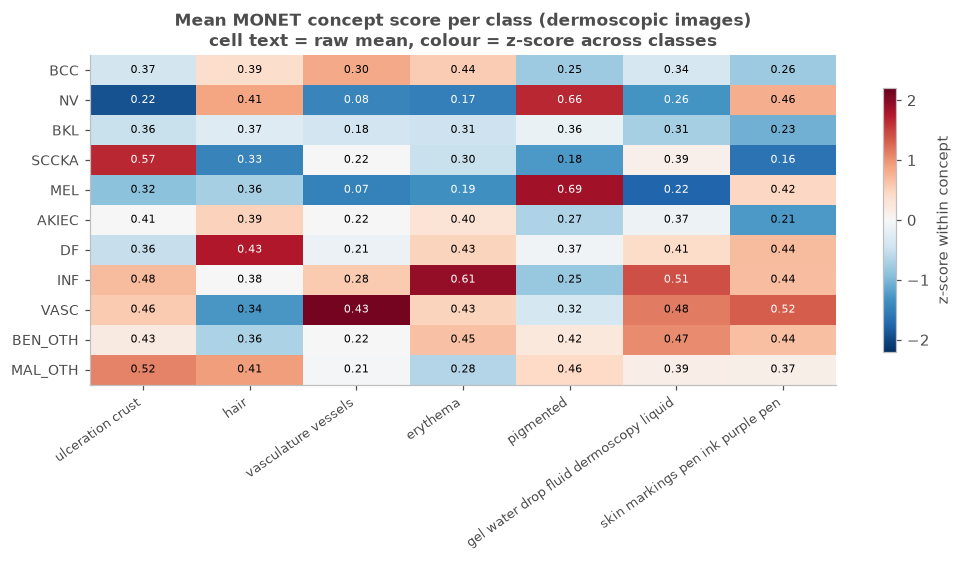

In [34]:
plots.plot_monet_by_class(df, save_as="fig15_monet_by_class.png")
plt.show()

Read row by row: VASC scores highest on `vasculature_vessels`, INF on `erythema`,
NV on `pigmented`. The concepts behave the way a dermatologist would expect, which is a
good sign that they carry real signal rather than noise.

## 10. What the EDA tells us to do next

| # | Finding | Consequence for the pipeline |
|---|---|---|
| 1 | Every lesion has exactly 2 images | Split on `lesion_id` with a grouped split. A random row split leaks every lesion. |
| 2 | 69.4% of lesions are Malignant | Never report bare accuracy. Use balanced accuracy, macro-F1, per-class recall, and malignant sensitivity. |
| 3 | 11-class imbalance is 280:1 | Class weights / oversampling, or merge the rare tail. Report per-class recall. |
| 4 | Two imaging modalities with different pixel statistics | Treat `image_type` explicitly — stratify, condition, or use two heads. |
| 5 | AKIEC straddles Indeterminate and Malignant | The 3-class target is not derivable from the 11-class code. Pick one target and be explicit. |
| 6 | Site missing 37%, melanocytic missing 77% | Metadata features need an explicit "unknown" category, not imputation-by-mode. |
| 7 | 61% of lesions are one skin tone class | Report per-skin-tone metrics. Aggregate numbers will hide group failures. |
| 8 | Images vary in size | Resize/crop is mandatory; decide and document the target resolution. |
| 9 | Dataset is biopsy-referred, not population-representative | A model here estimates "malignant *given a specialist was already worried*" — state this in any claim. |

**Next session:** image representation and normalisation, then the first baseline —
with a grouped split and malignant recall as the metric that counts.